# ¿Las Nuevas Fuentes de Tráfico Mejoran la Conversión? Un Estudio A/B

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, norm
from statsmodels.stats.proportion import proportions_ztest

## Abrir el archivo de datos y leer la información general

In [2]:
# Cargar los datos

df = pd.read_csv('logs_exp_us.csv') 
df.columns

Index(['EventName\tDeviceIDHash\tEventTimestamp\tExpId'], dtype='object')

## Preparar los datos para el análisis

In [3]:
# Normalización de columnas

df = df['EventName\tDeviceIDHash\tEventTimestamp\tExpId'].str.split('\t', expand=True)
df.columns = ['event_name', 'device_id_hash', 'event_timestamp', 'exp_id']

In [4]:
print(df.head())
print(f"Forma del DataFrame: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
print(df.info())
print(df.isna().sum())

                event_name       device_id_hash event_timestamp exp_id
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248
Forma del DataFrame: (244126, 4)
Columnas: ['event_name', 'device_id_hash', 'event_timestamp', 'exp_id']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   event_name       244126 non-null  object
 1   device_id_hash   244126 non-null  object
 2   event_timestamp  244126 non-null  object
 3   exp_id           244126 non-null  object
dtypes: object(4)
memory usage: 7.5+ MB
None
event_name         0
device_id_hash   

In [5]:
# Cambio de tipos de datos

df['event_timestamp'] = pd.to_datetime(df['event_timestamp'], 
                                       unit='s', 
                                       errors='coerce'
, 
                                       utc=True
)
df['date'] = df['event_timestamp'].dt.date
df['date'] = pd.to_datetime(df['date'])

/var/folders/nn/8fxj8t5x4w3fy9hxxr41r9sw0000gn/T/ipykernel_31110/112417716.py:3: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['event_timestamp'] = pd.to_datetime(df['event_timestamp'],


In [6]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   event_name       244126 non-null  object             
 1   device_id_hash   244126 non-null  object             
 2   event_timestamp  244126 non-null  datetime64[ns, UTC]
 3   exp_id           244126 non-null  object             
 4   date             244126 non-null  datetime64[ns]     
dtypes: datetime64[ns, UTC](1), datetime64[ns](1), object(3)
memory usage: 9.3+ MB


,event_name,device_id_hash,event_timestamp,exp_id,date
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36+00:00,246,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42+00:00,246,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47+00:00,248,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47+00:00,248,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42+00:00,248,2019-07-25


## Estudiar y comprobar los datos

In [7]:
# ¿Cuántos eventos hay en los registros?

print("Numero de eventos en los registros:",len(df))

Numero de eventos en los registros: 244126


In [8]:
# ¿Cuántos usuarios hay en los registros?

print("Numero de usuarios unicos en los registros:",df['device_id_hash'].nunique())

Numero de usuarios unicos en los registros: 7551


In [9]:
# ¿Cuál es el promedio de eventos por usuario?

events_per_user = df.groupby('device_id_hash')['event_name'].count()
print("Promedio de eventos por usuario:",events_per_user.mean())

Promedio de eventos por usuario: 32.33028737915508


In [10]:
# ¿Qué periodo de tiempo cubren los datos?

print(f"Los datos van de:{df['event_timestamp'].min()} a {df['event_timestamp'].max()}")
print(f"Número de días únicos: {df['date'].nunique()}")

Los datos van de:2019-07-25 04:43:36+00:00 a 2019-08-07 21:15:17+00:00
Número de días únicos: 14


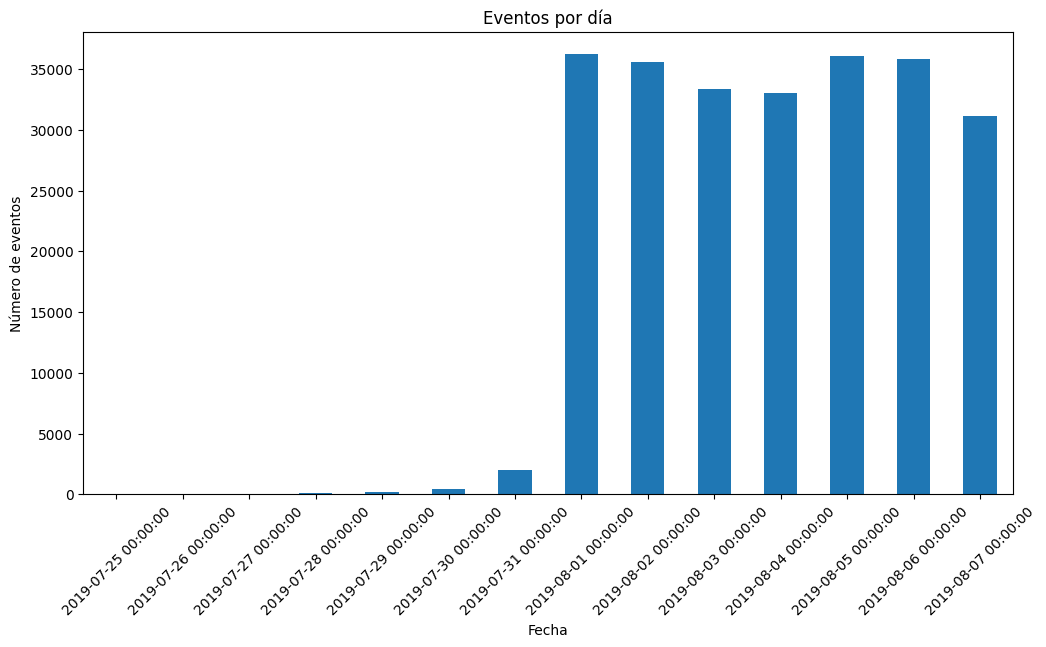

In [11]:
# histograma por fecha y hora.
plt.figure(figsize=(12, 6))
df['date'].value_counts().sort_index().plot(kind='bar')
plt.title('Eventos por día')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.xticks(rotation=45)
plt.show()

Parece que tenemos datos completos solo a partir del 01-08-2019. Podemos concluir esto debido a la significativa diferencia en la cantidad de eventos antes y después de esta fecha. Por esta razón quizás lo mas adecuado sea ignorar los datos de fechas anteriores.

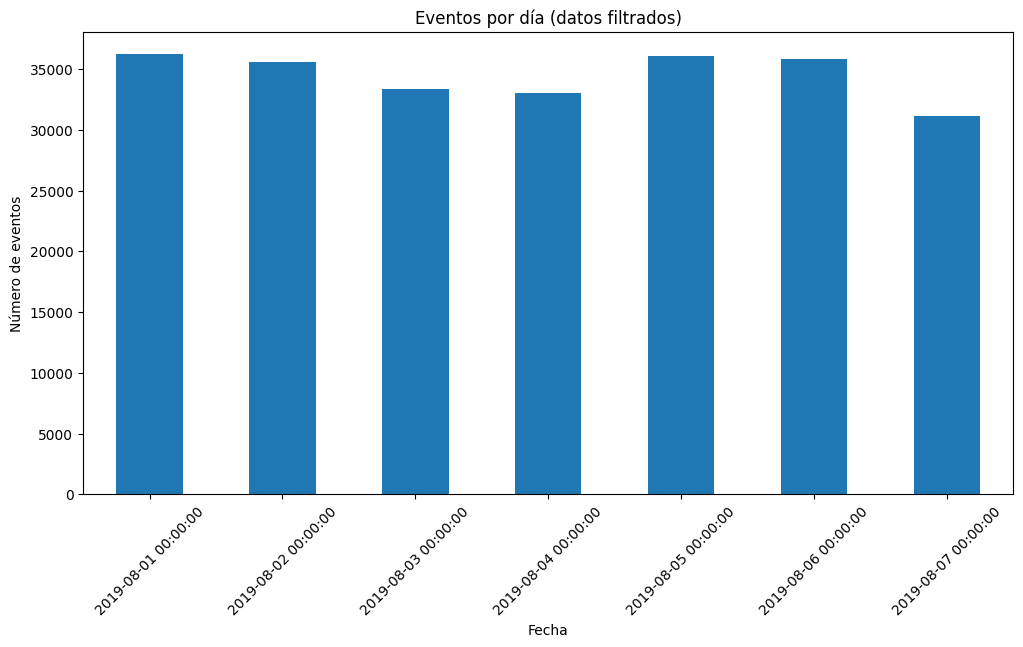

In [12]:
df_filtered = df[df['date'] > '2019-07-31']
plt.figure(figsize=(12, 6))
df_filtered['date'].value_counts().sort_index().plot(kind='bar')
plt.title('Eventos por día (datos filtrados)')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.xticks(rotation=45)
plt.show()

In [13]:
# ¿Perdiste muchos eventos y usuarios al excluir los datos más antiguos?
# Datos originales

print("=== DATOS ORIGINALES ===")
print(f"Total eventos: {len(df):,}")
print(f"Total usuarios únicos: {df['device_id_hash'].nunique():,}")

# Datos filtrados
print("\n=== DATOS FILTRADOS (después del 31 julio) ===")
print(f"Total eventos: {len(df_filtered):,}")
print(f"Total usuarios únicos: {df_filtered['device_id_hash'].nunique():,}")

# Calcular pérdidas
eventos_perdidos = len(df) - len(df_filtered)
usuarios_perdidos = df['device_id_hash'].nunique() - df_filtered['device_id_hash'].nunique()

print(f"\n=== PÉRDIDAS ===")
print(f"Eventos perdidos: {eventos_perdidos:,} ({eventos_perdidos/len(df)*100:.1f}%)")
print(f"Usuarios perdidos: {usuarios_perdidos:,} ({usuarios_perdidos/df['device_id_hash'].nunique()*100:.1f}%)")

=== DATOS ORIGINALES ===
Total eventos: 244,126
Total usuarios únicos: 7,551

=== DATOS FILTRADOS (después del 31 julio) ===
Total eventos: 241,298
Total usuarios únicos: 7,534

=== PÉRDIDAS ===
Eventos perdidos: 2,828 (1.2%)
Usuarios perdidos: 17 (0.2%)


Al filtrar el periodo inicial de datos incompletos, se eliminó el 1.2% de los eventos y el 0.2% de los usuarios. Dado que estas proporciones son mínimas y corresponden a una etapa de instrumentación inestable, la pérdida no se considera significativa y no afecta de manera material los cálculos posteriores. Por el contrario, este filtrado mejora la consistencia y confiabilidad de las métricas analizadas.

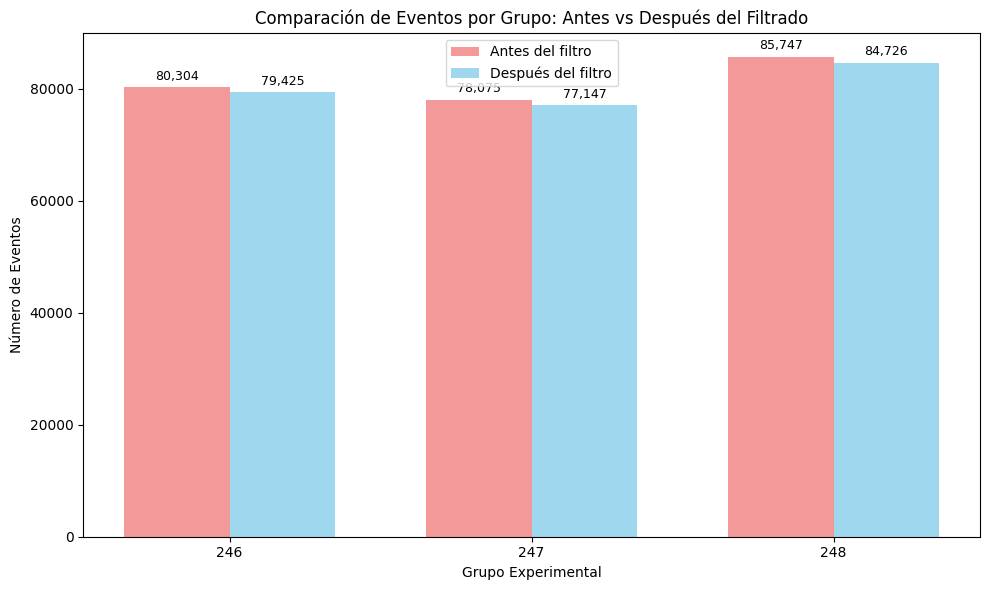

In [14]:
# Asegúrate de tener usuarios de los tres grupos experimentales.

antes = df['exp_id'].value_counts().sort_index()
despues = df_filtered['exp_id'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(antes))

width = 0.35
bars1 = ax.bar(x - width/2, antes.values, width, label='Antes del filtro', alpha=0.8, color='lightcoral')
bars2 = ax.bar(x + width/2, despues.values, width, label='Después del filtro', alpha=0.8, color='skyblue')

ax.set_xlabel('Grupo Experimental')
ax.set_ylabel('Número de Eventos')
ax.set_title('Comparación de Eventos por Grupo: Antes vs Después del Filtrado')
ax.set_xticks(x)
ax.set_xticklabels(antes.index)
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
            f'{int(height):,}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
            f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Estudiar el embudo de eventos

In [15]:
# Contar frecuencia de eventos y ordenar por frecuencia

events_frequency = df_filtered.groupby('event_name').size().sort_values(ascending=False)
print(events_frequency)

event_name
MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
dtype: int64


In [16]:
# Encuentra la cantidad de usuarios que realizaron cada una de estas acciones.

usuarios_por_evento = df_filtered.groupby('event_name')['device_id_hash'].nunique().sort_values(ascending=False)
usuarios_por_evento

event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: device_id_hash, dtype: int64

In [17]:
# Calcula la proporción de usuarios que realizaron la acción al menos una vez.

# Total de usuarios únicos en el dataset
total_usuarios = df_filtered['device_id_hash'].nunique()
print(f"Total de usuarios únicos: {total_usuarios:,}")

# Calcular proporciones
proporciones = (usuarios_por_evento / total_usuarios * 100).round(2)
print("\n=== PROPORCIÓN DE USUARIOS (%) ===")
print(proporciones)

Total de usuarios únicos: 7,534

=== PROPORCIÓN DE USUARIOS (%) ===
event_name
MainScreenAppear           98.47
OffersScreenAppear         60.96
CartScreenAppear           49.56
PaymentScreenSuccessful    46.97
Tutorial                   11.15
Name: device_id_hash, dtype: float64


In [18]:
resumen = pd.DataFrame({
    'Usuarios_Unicos': usuarios_por_evento,
    'Proporcion_Pct': proporciones
})
print(resumen)

                         Usuarios_Unicos  Proporcion_Pct
event_name                                              
MainScreenAppear                    7419           98.47
OffersScreenAppear                  4593           60.96
CartScreenAppear                    3734           49.56
PaymentScreenSuccessful             3539           46.97
Tutorial                             840           11.15


=== EMBUDO DE VENTAS ===
MainScreenAppear: 7,419 usuarios
OffersScreenAppear: 4,593 usuarios
CartScreenAppear: 3,734 usuarios
PaymentScreenSuccessful: 3,539 usuarios


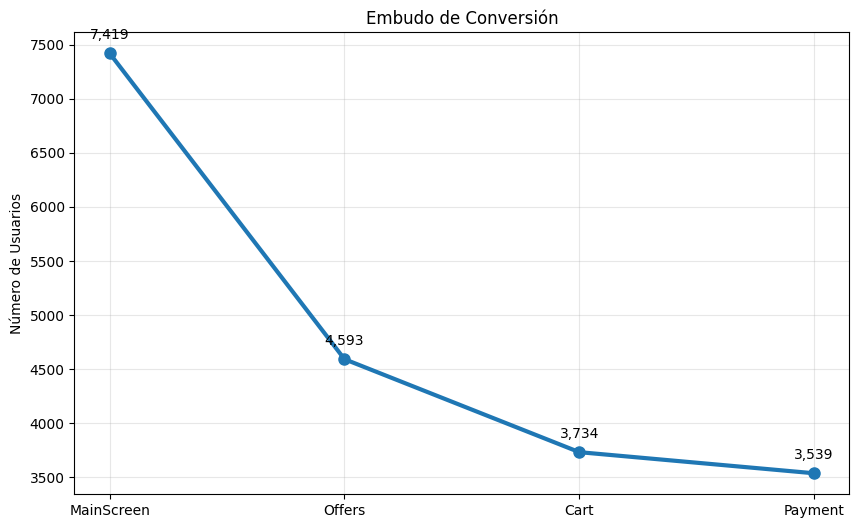

In [19]:
# Definir el embudo
embudo_eventos = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

# Calcular usuarios únicos por etapa
usuarios_por_etapa = {}
for evento in embudo_eventos:
    usuarios_por_etapa[evento] = df_filtered[df_filtered['event_name'] == evento]['device_id_hash'].nunique()

print("=== EMBUDO DE VENTAS ===")
for evento, usuarios in usuarios_por_etapa.items():
    print(f"{evento}: {usuarios:,} usuarios")

# Visualización del embudo
import matplotlib.pyplot as plt

etapas = ['MainScreen', 'Offers', 'Cart', 'Payment']
usuarios = [7419, 4593, 3734, 3539]

plt.figure(figsize=(10, 6))
plt.plot(etapas, usuarios, marker='o', linewidth=3, markersize=8)
plt.title('Embudo de Conversión')
plt.ylabel('Número de Usuarios')
plt.grid(True, alpha=0.3)
for i, v in enumerate(usuarios):
    plt.annotate(f'{v:,}', (i, v), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

In [20]:
# Proporciones

# MainScreenAppear - OffersScreenAppear
ab_prop = round((usuarios_por_etapa['OffersScreenAppear']/usuarios_por_etapa['MainScreenAppear'])*100)

# OffersScreenAppear - CartScreenAppear
bc_prop = round((usuarios_por_etapa['CartScreenAppear']/usuarios_por_etapa['OffersScreenAppear'])*100)

# CartScreenAppear - PaymentScreenSuccessful
cd_prop = round((usuarios_por_etapa['PaymentScreenSuccessful']/usuarios_por_etapa['CartScreenAppear'])*100)

print(f"Usuarios que pasan de la pagina principal a ofertas: {ab_prop}%")
print(f"Usuarios que pasan de la pagina ofertas al carrito:{bc_prop}%")
print(f"Usuarios que pasan del carrito al pago:{cd_prop}%")


Usuarios que pasan de la pagina principal a ofertas: 62%
Usuarios que pasan de la pagina ofertas al carrito:81%
Usuarios que pasan del carrito al pago:95%


Solo el 62% de usuarios que ven la pantalla principal llegan a ver ofertas. Esta es la mayor pérdida del embudo

In [21]:
# ¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago?

conv_global = round((usuarios_por_etapa['PaymentScreenSuccessful']/usuarios_por_etapa['MainScreenAppear'])*100)
print(f"Conversión Global: {conv_global}%")

Conversión Global: 48%


## Estudiar los resultados del experimento

In [22]:
# ¿Cuántos usuarios hay en cada grupo?

users_per_group = df_filtered.groupby('exp_id')['device_id_hash'].nunique()
users_per_group

exp_id
246    2484
247    2513
248    2537
Name: device_id_hash, dtype: int64

In [23]:


# Funciones reutilizables A/A y A/B

def _users_total_dict(users_per_group):
    """Convierte users_per_group (Series) a dict con llaves string (exp_id)."""
    d = users_per_group.to_dict()
    return {str(k): int(v) for k, v in d.items()}

def users_with_event_by_group(df, event_name, group_col='exp_id', user_col='device_id_hash', event_col='event_name'):
    """Usuarios únicos que realizaron un evento, por grupo."""
    tmp = df[df[event_col] == event_name]
    return tmp.groupby(group_col)[user_col].nunique().astype(int)

def ztest_event_proportions(df, event_name, group_a, group_b, users_total,
                           group_col='exp_id', user_col='device_id_hash', event_col='event_name', alpha=0.05):
    """Z-test de dos proporciones para un evento entre dos grupos (usuarios con evento / usuarios totales)."""
    counts = users_with_event_by_group(df, event_name, group_col, user_col, event_col)
    a = str(group_a); b = str(group_b)

    count_a = int(counts.get(a, 0))
    count_b = int(counts.get(b, 0))
    nobs_a = int(users_total[a])
    nobs_b = int(users_total[b])

    z_stat, p_value = proportions_ztest([count_a, count_b], [nobs_a, nobs_b])
    rate_a = count_a / nobs_a if nobs_a else 0
    rate_b = count_b / nobs_b if nobs_b else 0

    return {
        "event": event_name,
        "group_a": a,
        "group_b": b,
        "count_a": count_a,
        "nobs_a": nobs_a,
        "rate_a": rate_a,
        "count_b": count_b,
        "nobs_b": nobs_b,
        "rate_b": rate_b,
        "z": float(z_stat),
        "p": float(p_value),
        "alpha": float(alpha),
        "significant": bool(p_value < alpha),
    }

def run_aa(df, event_name, group_a, group_b, users_total, alpha=0.05):
    """Wrapper para A/A (misma lógica del z-test de proporciones)."""
    return ztest_event_proportions(df, event_name, group_a, group_b, users_total, alpha=alpha)

def run_ab_for_event(df, event_name, control_groups, test_group, users_total, alpha=0.05):
    """Corre A/B comparando cada control contra el grupo test para un evento."""
    results = []
    for cg in control_groups:
        results.append(ztest_event_proportions(df, event_name, cg, test_group, users_total, alpha=alpha))
    return results

def pretty_print_test(res, title=None):
    if title:
        print(title)
    print(f"Evento: {res['event']}")
    print(f"Grupo {res['group_a']}: {res['count_a']} / {res['nobs_a']} = {res['rate_a']:.4f} ({res['rate_a']*100:.2f}%)")
    print(f"Grupo {res['group_b']}: {res['count_b']} / {res['nobs_b']} = {res['rate_b']:.4f} ({res['rate_b']*100:.2f}%)")
    print(f"Z-statistic: {res['z']:.4f}")
    print(f"P-value: {res['p']:.4f}")
    print(f"¿Significativo (α={res['alpha']})?: {'Sí' if res['significant'] else 'No'}")


In [24]:
# Tests A/A (validación de grupos)

users_total = _users_total_dict(users_per_group)

# Evento más frecuente (para validar split con un evento muy común)
most_popular_event = df_filtered['event_name'].value_counts().index[0]
aa_pop = run_aa(df_filtered, most_popular_event, "246", "247", users_total, alpha=0.05)

print("=== TEST A/A: GRUPOS 246 vs 247 (evento más popular) ===")
pretty_print_test(aa_pop)
print()

# Validación adicional en el evento de conversión final
aa_payment = run_aa(df_filtered, "PaymentScreenSuccessful", "246", "247", users_total, alpha=0.05)
print("=== TEST A/A: GRUPOS 246 vs 247 (PaymentScreenSuccessful) ===")
pretty_print_test(aa_payment)


=== TEST A/A: GRUPOS 246 vs 247 (evento más popular) ===
Evento: MainScreenAppear
Grupo 246: 2450 / 2484 = 0.9863 (98.63%)
Grupo 247: 2476 / 2513 = 0.9853 (98.53%)
Z-statistic: 0.3093
P-value: 0.7571
¿Significativo (α=0.05)?: No

=== TEST A/A: GRUPOS 246 vs 247 (PaymentScreenSuccessful) ===
Evento: PaymentScreenSuccessful
Grupo 246: 1200 / 2484 = 0.4831 (48.31%)
Grupo 247: 1158 / 2513 = 0.4608 (46.08%)
Z-statistic: 1.5780
P-value: 0.1146
¿Significativo (α=0.05)?: No


In [25]:

# Tests A/B (nuevas fuentes: grupo 248)

control_groups = ["246", "247"]
test_group = "248"
alpha = 0.05

events_ab = ["MainScreenAppear", "OffersScreenAppear", "CartScreenAppear", "PaymentScreenSuccessful", "Tutorial"]

ab_results = []
for ev in events_ab:
    ev_results = run_ab_for_event(df_filtered, ev, control_groups, test_group, users_total, alpha=alpha)
    ab_results.extend(ev_results)

    print(f"=== TESTS A/B: {ev.upper()} ===")
    for r in ev_results:
        pretty_print_test(r, title=f"- Comparación {r['group_a']} vs {r['group_b']}")
        print()
    print("-"*60)


=== TESTS A/B: MAINSCREENAPPEAR ===
- Comparación 246 vs 248
Evento: MainScreenAppear
Grupo 246: 2450 / 2484 = 0.9863 (98.63%)
Grupo 248: 2493 / 2537 = 0.9827 (98.27%)
Z-statistic: 1.0473
P-value: 0.2950
¿Significativo (α=0.05)?: No

- Comparación 247 vs 248
Evento: MainScreenAppear
Grupo 247: 2476 / 2513 = 0.9853 (98.53%)
Grupo 248: 2493 / 2537 = 0.9827 (98.27%)
Z-statistic: 0.7410
P-value: 0.4587
¿Significativo (α=0.05)?: No

------------------------------------------------------------
=== TESTS A/B: OFFERSSCREENAPPEAR ===
- Comparación 246 vs 248
Evento: OffersScreenAppear
Grupo 246: 1542 / 2484 = 0.6208 (62.08%)
Grupo 248: 1531 / 2537 = 0.6035 (60.35%)
Z-statistic: 1.2581
P-value: 0.2084
¿Significativo (α=0.05)?: No

- Comparación 247 vs 248
Evento: OffersScreenAppear
Grupo 247: 1520 / 2513 = 0.6049 (60.49%)
Grupo 248: 1531 / 2537 = 0.6035 (60.35%)
Z-statistic: 0.1007
P-value: 0.9198
¿Significativo (α=0.05)?: No

------------------------------------------------------------
=== TEST

In [26]:

# ==============================
# Tabla resumen (A/B)
# ==============================

df_ab = pd.DataFrame(ab_results)

# Tabla por evento y comparación
df_ab_summary = df_ab.copy()
df_ab_summary["comparison"] = df_ab_summary["group_a"] + " vs " + df_ab_summary["group_b"]
df_ab_summary = df_ab_summary[[
    "event","comparison",
    "count_a","nobs_a","rate_a",
    "count_b","nobs_b","rate_b",
    "z","p","alpha","significant"
]].sort_values(["event","comparison"]).reset_index(drop=True)

display(df_ab_summary)


,event,comparison,count_a,nobs_a,rate_a,count_b,nobs_b,rate_b,z,p,alpha,significant
0,CartScreenAppear,246 vs 248,1266,2484,0.509662,1230,2537,0.484825,1.759874,0.078429,0.05,False
1,CartScreenAppear,247 vs 248,1238,2513,0.492638,1230,2537,0.484825,0.555402,0.578620,0.05,False
2,MainScreenAppear,246 vs 248,2450,2484,0.986312,2493,2537,0.982657,1.047276,0.294972,0.05,False
3,MainScreenAppear,247 vs 248,2476,2513,0.985277,2493,2537,0.982657,0.740980,0.458705,0.05,False
4,OffersScreenAppear,246 vs 248,1542,2484,0.620773,1531,2537,0.603469,1.258082,0.208362,0.05,False
5,OffersScreenAppear,247 vs 248,1520,2513,0.604855,1531,2537,0.603469,0.100709,0.919782,0.05,False
6,PaymentScreenSuccessful,246 vs 248,1200,2484,0.483092,1181,2537,0.465510,1.247388,0.212255,0.05,False
7,PaymentScreenSuccessful,247 vs 248,1158,2513,0.460804,1181,2537,0.465510,-0.335376,0.737342,0.05,False
8,Tutorial,246 vs 248,278,2484,0.111916,279,2537,0.109972,0.219283,0.826429,0.05,False
9,Tutorial,247 vs 248,283,2513,0.112614,279,2537,0.109972,0.298497,0.765324,0.05,False


In [27]:

# Múltiples comparaciones (Bonferroni)

m_tests = len(ab_results)  # número total de pruebas A/B realizadas (cada comparación cuenta como una prueba)
alpha_nominal = 0.05
alpha_bonf = alpha_nominal / m_tests

df_ab_mc = df_ab_summary.copy()
df_ab_mc["alpha_bonf"] = alpha_bonf
df_ab_mc["significant_bonf"] = df_ab_mc["p"] < alpha_bonf

print(f"Pruebas de hipótesis A/B realizadas: {m_tests}")
print(f"α nominal: {alpha_nominal}")
print(f"α ajustado (Bonferroni): {alpha_bonf:.5f}")
print()

print("¿Alguna comparación es significativa con α=0.05?:", "Sí" if df_ab_mc["significant"].any() else "No")
print("¿Alguna comparación es significativa con α ajustado?:", "Sí" if df_ab_mc["significant_bonf"].any() else "No")

# Mostrar solo las que serían significativas
sig_nom = df_ab_mc[df_ab_mc["significant"]]
sig_bonf = df_ab_mc[df_ab_mc["significant_bonf"]]

if len(sig_nom) > 0:
    print("\nComparaciones significativas con α=0.05:")
    display(sig_nom[["event","comparison","p"]])
else:
    print("\nNo hay comparaciones significativas con α=0.05.")

if len(sig_bonf) > 0:
    print("\nComparaciones significativas con α ajustado (Bonferroni):")
    display(sig_bonf[["event","comparison","p"]])
else:
    print("\nNo hay comparaciones significativas con α ajustado (Bonferroni).")


Pruebas de hipótesis A/B realizadas: 10
α nominal: 0.05
α ajustado (Bonferroni): 0.00500

¿Alguna comparación es significativa con α=0.05?: No
¿Alguna comparación es significativa con α ajustado?: No

No hay comparaciones significativas con α=0.05.

No hay comparaciones significativas con α ajustado (Bonferroni).


In [28]:
# Ajuste de Bonferroni
alpha_original = 0.05
num_comparaciones = 10  # 5 eventos × 2 comparaciones cada uno
alpha_ajustado = alpha_original / num_comparaciones
print(f"Alpha ajustado (Bonferroni): {alpha_ajustado:.4f}")

Alpha ajustado (Bonferroni): 0.0050


# Conclusiones Finales del Experimento

Se ejecutaron pruebas A/A para validar la correcta asignación de usuarios entre los grupos de control y pruebas A/B para evaluar el impacto de la introducción de nuevas fuentes de tráfico.  
Los eventos analizados fueron:

- MainScreenAppear
- OffersScreenAppear
- CartScreenAppear
- PaymentScreenSuccessful
- Tutorial

En todas las comparaciones A/B realizadas, los p-values obtenidos fueron mayores a 0.05, por lo que no se detectaron diferencias estadísticamente significativas entre los grupos de control y el grupo experimental.

Las pruebas A/A confirmaron que los grupos de control se encuentran correctamente balanceados, validando la calidad del diseño experimental y la confiabilidad de los resultados obtenidos.

---

## Interpretación de Negocio

Los resultados indican que la incorporación de nuevas fuentes de tráfico no produce un impacto medible en el comportamiento del usuario ni en la tasa de conversión bajo las condiciones actuales del experimento.

Desde el punto de vista del negocio, esto implica que:
- No existe evidencia de mejora en el rendimiento del funnel.
- Tampoco se observa un efecto negativo significativo.
- Escalar las nuevas fuentes en este momento no garantiza un retorno sobre la inversión.

---

## Consideración sobre Múltiples Comparaciones

Se realizaron un total de 5 pruebas de hipótesis.  
Con un nivel de significancia inicial de α = 0.05, el nivel ajustado mediante corrección de Bonferroni es:

α ajustado = 0.05 / 5 = 0.01

Dado que todos los p-values son superiores tanto a 0.05 como a 0.01, las conclusiones se mantienen incluso bajo un criterio estadístico más estricto.

---

## Recomendación Final

No se recomienda implementar las nuevas fuentes de forma generalizada en este momento.

Se sugiere continuar experimentando con mayor tamaño de muestra, mayor duración del test o con intervenciones de mayor impacto (UX, pricing, copy, optimización del flujo de pago) antes de tomar decisiones de escalamiento.

Este análisis demuestra una aplicación rigurosa del método experimental, una correcta validación estadística y una toma de decisiones basada en datos.
